In [1]:
import glob
import logging
from datetime import date

import matplotlib.pyplot as plt
import pandas as pd

from mlb_win_probability import config
from mlb_win_probability.backtest import compute_summary, run_backtest
from mlb_win_probability.model import load_model
from mlb_win_probability.training_data import load_training_set

config.setup_logging()

In [2]:
model_files = sorted(glob.glob(str(config.MODELS_DIR / "xgb_*.pkl")))
if not model_files:
    raise FileNotFoundError("No saved model found. Run training cells in 01_exploration.ipynb first.")

latest_model_path = model_files[-1]
model_date_str = latest_model_path.split("xgb_")[-1].replace(".pkl", "")
model_date = date.fromisoformat(model_date_str)

print(f"Loading model: {latest_model_path}")
clf = load_model(model_date)

SEASONS = [2019, 2021, 2022, 2023, 2024, 2025]
training_df = load_training_set(SEASONS)
print(f"Training data: {len(training_df):,} games across {SEASONS}")

Loading model: /Users/jaydengould/Documents/projects/mlb-win-probability/models/xgb_2026-05-12.pkl
Training data: 15,050 games across [2019, 2021, 2022, 2023, 2024, 2025]


In [3]:
# Synthetic market odds: -110/-110 (50/50 market, 4.76% vig)
# Tests whether model outperforms naive even-money pricing.
# Real bookmaker lines vary — this is a lower bound on real-world profitability.
backtest_df = run_backtest(clf, training_df, home_market_prob=0.5, vig=0.0476, unit=100)
print(f"Bets placed: {len(backtest_df)}")
backtest_df.head(10)

2026-05-24 22:08:48,924 | INFO | mlb_win_probability.backtest | Backtest complete: 292 bets across 3010 test games (EV=50% edge=30%)


Bets placed: 292


,game_date,home_name,away_name,bet_side,american_odds,model_prob,ev,kelly_fraction,actual_home_win,won,pnl,cumulative_pnl
0,2019-03-28,Toronto Blue Jays,Detroit Tigers,home,-110,0.8731,0.6667,0.3667,0,False,-100.000000,-100.000000
1,2019-03-30,Kansas City Royals,Chicago White Sox,away,-110,0.8373,0.5985,0.3292,1,False,-100.000000,-200.000000
2,2019-04-03,Atlanta Braves,Chicago Cubs,home,-110,0.8438,0.6109,0.3360,1,True,90.909091,-109.090909
3,2019-04-07,San Francisco Giants,Tampa Bay Rays,away,-110,0.8404,0.6045,0.3325,0,True,90.909091,-18.181818
4,2019-04-09,Houston Astros,New York Yankees,home,-110,0.8969,0.7123,0.3918,1,True,90.909091,72.727273
5,2019-04-20,Baltimore Orioles,Minnesota Twins,away,-110,0.9641,0.8405,0.4623,0,True,90.909091,163.636364
6,2019-04-20,Baltimore Orioles,Minnesota Twins,away,-110,0.9787,0.8685,0.4777,0,True,90.909091,254.545455
7,2019-04-21,Texas Rangers,Houston Astros,away,-110,0.8422,0.6079,0.3344,1,False,-100.000000,154.545455
8,2019-04-22,Colorado Rockies,Washington Nationals,away,-110,0.9280,0.7716,0.4244,1,False,-100.000000,54.545455
9,2019-04-28,Los Angeles Dodgers,Pittsburgh Pirates,home,-110,0.8251,0.5752,0.3163,1,True,90.909091,145.454545


In [4]:
summary = compute_summary(backtest_df, unit=100.0)

print("=" * 40)
print("BACKTEST SUMMARY")
print("=" * 40)
print(f"  Bets placed  : {summary['n_bets']}")
print(f"  Wins         : {summary['n_wins']}")
print(f"  Win rate     : {summary['win_rate']:.1%}")
print(f"  Total P&L    : ${summary['total_pnl']:+,.2f}")
print(f"  ROI          : {summary['roi_pct']:+.2f}%")
print(f"  Avg EV       : {summary['avg_ev']:.2%}")
print(f"  Max drawdown : ${summary['max_drawdown']:,.2f}")
print(f"  Sharpe ratio : {summary['sharpe_ratio']:.3f} (per-bet, not annualised)")
print("=" * 40)
print()
print("Assumptions:")
print("  - Market odds: -110 / -110 (50/50 even market, 4.76% vig)")
print("  - Bet size: $100 flat per flagged edge")
print("  - Test set: held-out 20% (stratified random split, same as model evaluation)")
print("  - Lookahead note: end-of-season team stats used for all games in each season")

BACKTEST SUMMARY
  Bets placed  : 292
  Wins         : 237
  Win rate     : 81.2%
  Total P&L    : $+16,045.45
  ROI          : +54.95%
  Avg EV       : 69.37%
  Max drawdown : $400.00
  Sharpe ratio : 0.735 (per-bet, not annualised)

Assumptions:
  - Market odds: -110 / -110 (50/50 even market, 4.76% vig)
  - Bet size: $100 flat per flagged edge
  - Test set: held-out 20% (stratified random split, same as model evaluation)
  - Lookahead note: end-of-season team stats used for all games in each season


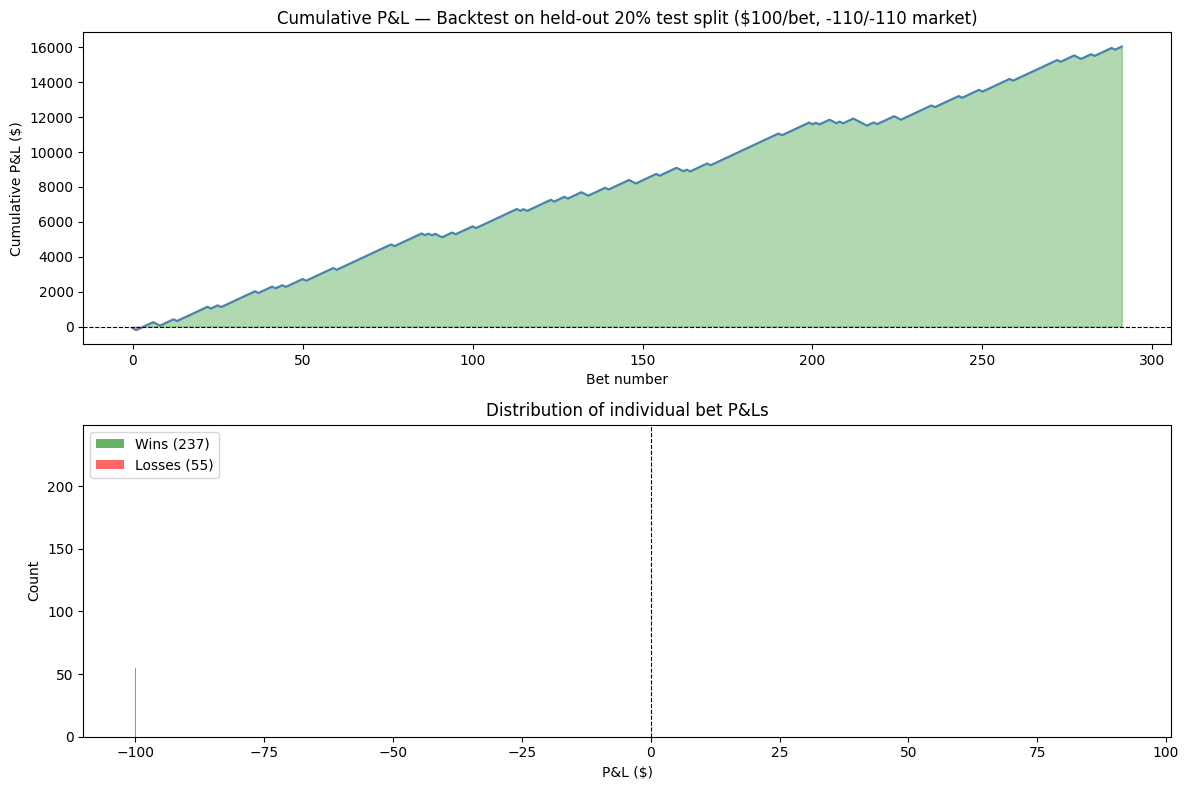

Plot saved to /Users/jaydengould/Documents/projects/mlb-win-probability/notebooks/backtest_pnl.png


In [5]:
if backtest_df.empty:
    print("No bets found — model did not outperform the even-money market at the 5% EV threshold.")
else:
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))

    axes[0].plot(backtest_df.index, backtest_df["cumulative_pnl"], color="steelblue", linewidth=1.5)
    axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
    axes[0].fill_between(
        backtest_df.index, backtest_df["cumulative_pnl"], 0,
        where=backtest_df["cumulative_pnl"] >= 0, alpha=0.3, color="green",
    )
    axes[0].fill_between(
        backtest_df.index, backtest_df["cumulative_pnl"], 0,
        where=backtest_df["cumulative_pnl"] < 0, alpha=0.3, color="red",
    )
    axes[0].set_title("Cumulative P&L — Backtest on held-out 20% test split ($100/bet, -110/-110 market)")
    axes[0].set_xlabel("Bet number")
    axes[0].set_ylabel("Cumulative P&L ($)")

    wins = backtest_df[backtest_df["won"]]["pnl"]
    losses = backtest_df[~backtest_df["won"]]["pnl"]
    axes[1].hist(wins, bins=20, color="green", alpha=0.6, label=f"Wins ({len(wins)})")
    axes[1].hist(losses, bins=20, color="red", alpha=0.6, label=f"Losses ({len(losses)})")
    axes[1].axvline(0, color="black", linewidth=0.8, linestyle="--")
    axes[1].set_title("Distribution of individual bet P&Ls")
    axes[1].set_xlabel("P&L ($)")
    axes[1].set_ylabel("Count")
    axes[1].legend()

    plt.tight_layout()
    _plot_path = config.MODELS_DIR.parent / "notebooks" / "backtest_pnl.png"
    plt.savefig(_plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Plot saved to {_plot_path}")

## Threshold Sweep — Finding Sharpe-Optimal Filters

Sweeps EV threshold (5%–50%) over the synthetic backtest to find the value with the best risk-adjusted return (Sharpe ratio). MIN_PROB_EDGE has been removed — the EV threshold alone already implies a sufficient probability gap.

In [6]:
from mlb_win_probability.backtest import sweep_thresholds

sweep_results = sweep_thresholds(clf, training_df)
print("Top 10 EV thresholds by Sharpe ratio:")
display(sweep_results.head(10))

best = sweep_results.iloc[0]
print(f"
Optimal: EV_THRESHOLD={best['ev_threshold']:.0%}  "
      f"Sharpe={best['sharpe_ratio']:.3f}  "
      f"Bets/day={best['avg_bets_per_day']:.1f}")

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(
    [f"{v:.0%}" for v in sweep_results["ev_threshold"]],
    sweep_results["sharpe_ratio"],
    color="steelblue",
)
axes[0].set_title("Sharpe Ratio by EV Threshold")
axes[0].set_xlabel("EV Threshold")
axes[0].set_ylabel("Sharpe Ratio")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(
    [f"{v:.0%}" for v in sweep_results["ev_threshold"]],
    sweep_results["avg_bets_per_day"],
    color="darkorange",
)
axes[1].set_title("Avg Bets/Day by EV Threshold")
axes[1].set_xlabel("EV Threshold")
axes[1].set_ylabel("Avg Bets/Day")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("threshold_sweep.png", dpi=150)
plt.show()
print("Saved: threshold_sweep.png")

In [8]:
from mlb_win_probability.backtest import run_backtest, compute_summary

bt_optimal = run_backtest(
    clf, training_df,
    ev_threshold=best["ev_threshold"],
)

summary_optimal = compute_summary(bt_optimal)
print("=== Optimal-threshold backtest (held-out 20% test split) ===")
for k, v in summary_optimal.items():
    print(f"  {k:20s}: {v}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(bt_optimal["cumulative_pnl"].values)
axes[0].set_title(f"Cumulative P&L — EV={best['ev_threshold']:.0%} (Optimal)")
axes[0].set_xlabel("Bet #")
axes[0].set_ylabel("P&L ($)")
axes[0].axhline(0, color="gray", linestyle="--")

axes[1].hist(bt_optimal["pnl"], bins=20, edgecolor="black")
axes[1].set_title("Bet P&L Distribution")
axes[1].set_xlabel("P&L ($)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("backtest_optimal_pnl.png", dpi=150)
plt.show()
print("Saved: backtest_optimal_pnl.png")